### 1. Liiketoiminnan ymmärrys

#### Tavoite
- Tutkia miten uni- ja liikuntatottumukset vaikuttavat hyvinvointiin ja aktiivisuustasoon.

#### Keskeiset kysymykset
- Onko unella, aktiivisuudella taikka fyysisellä kunnolla vaikutusta toisiinsa?
- Onko eri käyttäjäryhmillä selkeitä eroja unirytmissä ja liikuntamäärissä?
- Mitkä tekijät vaikuttavat unen määrään ja tasoon?

#### Vaadittava data
- Uni (kesto, taso)
- Liikunta (päivittäiset askeleet, aktiivisuusminuutit, kulutetut kalorit)
- Mahdollisesti lisämuuttujat (syke, stressitaso, unihäiriöt)

#### Mahdolliset rajoitteet
- Käyttäjien erilaiset elämäntyylit ja taustatekijät
- Älykellodatan mahdollinen epätarkkuus ja käyttämättömyys.
- Datan vajanaisuus ja puutteellisuus


#### Odotetut tulokset
- Käyttäjäryhmien (klusterien) löytäminen unirytmien ja aktiivisuustottumusten perusteella
- Ennustemalli, joka arvioi aktiivisuustason unen perusteella
- Ymmärrys siitä, miten uni vaikuttaa päivittäiseen aktiivisuustasoon ja fyysiseen hyvinvointiin.


## 2. Datan ymmärtäminen

#### Tietoa datasetistä

"Tämä aineisto on kerätty vastaajilta hajautetun kyselyn kautta Amazon Mechanical Turkin avulla ajanjaksolla 03.12.2016–05.12.2016. Kolmekymmentä kelpoisuusehdot täyttävää Fitbit-käyttäjää antoi suostumuksensa henkilökohtaisten aktiivisuusmittaridatojen lähettämiseen, mukaan lukien minuuttitasoiset tiedot fyysisestä aktiivisuudesta, sykkeestä ja unen seurannasta. Eri laitteiden ja käyttäjien yksilölliset seurantatavat ja mieltymykset aiheuttavat vaihtelua aineiston tuloksissa."


Lähde: https://www.kaggle.com/datasets/nurudeenabdulsalaam/fitbit-fitness-tracker-data/data

#### Tietoa muuttujista
1. Id: Käyttäjän yksilöivä tunniste
2. TotalSteps: Päivän aikana otetut askeleet
3. TotalDistance: Kuljettu matka kilometreissä
4. Calories: Arvio kulutetuista kaloreista
5. Sleep.Value: 1 = Sleep / 2 = restless / 3 = Awake

In [206]:
from operator import index
from pyexpat import features
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error


import correlation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.constants import minute
dailyData = pd.read_csv('archive/merged_daily_activity.csv')
weight_data = pd.read_csv('archive/weightLogInfo_merged.csv')


#### Datan rakenne

In [207]:
dailyData.loc[:]

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,SleepLevel_1,SleepLevel_2,SleepLevel_3,avg_heart_rate,sum_heart_rate,max_heart_rate,min_heart_rate
0,1503960366,2016-04-12,13162,8.500000,8.500000,0.0,1.88,0.55,6.06,0.00,...,1.0,327.0,346.0,0.945087,0.037572,0.017341,NaN,NaN,NaN,NaN
1,1503960366,2016-04-13,10735,6.970000,6.970000,0.0,1.57,0.69,4.71,0.00,...,2.0,384.0,407.0,0.943489,0.027027,0.029484,NaN,NaN,NaN,NaN
2,1503960366,2016-04-14,10460,6.740000,6.740000,0.0,2.44,0.40,3.91,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1503960366,2016-04-15,9762,6.280000,6.280000,0.0,2.14,1.26,2.83,0.00,...,1.0,412.0,442.0,0.932127,0.049774,0.018100,NaN,NaN,NaN,NaN
4,1503960366,2016-04-16,12669,8.160000,8.160000,0.0,2.71,0.41,5.04,0.00,...,2.0,340.0,367.0,0.930000,0.050000,0.020000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,8877689391,2016-05-08,10686,8.110000,8.110000,0.0,1.08,0.20,6.80,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,72.550523,464541.0,137.0,54.0
936,8877689391,2016-05-09,20226,18.250000,18.250000,0.0,11.10,0.80,6.24,0.05,...,NaN,NaN,NaN,NaN,NaN,NaN,89.615738,682155.0,176.0,51.0
937,8877689391,2016-05-10,10733,8.150000,8.150000,0.0,1.35,0.46,6.28,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,71.544377,446580.0,141.0,50.0
938,8877689391,2016-05-11,21420,19.559999,19.559999,0.0,13.22,0.41,5.89,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,89.149122,705437.0,180.0,48.0


In [208]:
dailyData.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,...,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,SleepLevel_1,SleepLevel_2,SleepLevel_3,avg_heart_rate,sum_heart_rate,max_heart_rate,min_heart_rate
count,9.400000e+02,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,...,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,334.000000,3.340000e+02,334.000000,334.000000
mean,4.855407e+09,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,...,1.126829,422.536585,461.995122,0.926034,0.072049,0.009234,78.614059,5.750220e+05,138.703593,52.691617
std,2.424805e+09,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,...,0.354520,126.298633,134.719431,0.121532,0.084275,0.011872,10.613254,3.633880e+05,21.687215,7.427171
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,58.000000,61.000000,0.459215,0.000000,0.000000,59.377175,1.554000e+03,80.000000,36.000000
25%,2.320127e+09,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,...,1.000000,361.000000,406.000000,0.915144,0.033055,0.001847,70.465679,4.355502e+05,125.000000,48.000000
50%,4.445115e+09,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,...,1.000000,433.000000,463.500000,0.943671,0.049698,0.006401,77.494179,5.522510e+05,135.500000,52.000000
75%,6.962181e+09,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,...,1.000000,492.000000,529.250000,0.962159,0.071429,0.011818,84.933171,6.655475e+05,153.000000,56.000000
max,8.877689e+09,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,...,3.000000,1040.000000,1086.000000,1.925170,0.519637,0.105973,109.789625,3.117672e+06,203.000000,71.000000


In [209]:
dailyData.dtypes

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
TotalSleepRecords           float64
TotalMinutesAsleep          float64
TotalTimeInBed              float64
SleepLevel_1                float64
SleepLevel_2                float64
SleepLevel_3                float64
avg_heart_rate              float64
sum_heart_rate              float64
max_heart_rate              float64
min_heart_rate              float64
dtype: object

In [210]:
weight_data.dtypes

Id                  int64
Date               object
WeightKg          float64
WeightPounds      float64
Fat               float64
BMI               float64
IsManualReport       bool
LogId               int64
dtype: object

### Havaintoja aktiivisuuteen ja uneen liittyvästä datasta
1. 0 arvoisia minimi arvoja. Eli voi olettaa että käyttäjät eivät ole käyttänneet laitettaan.
2. Tyhjiä arvoja joissakin sarakkeissa. Nämä poistetaan.
3. Epäloogista dataa, kuten negatiivisa arvoja ei ole.
4. Data on muuten valmiiksi käsiteltävissä, paitsi ActivityDate ja Date ovat objekteja. Ne täytyy muuttaa datetime muotoon.

In [211]:
print(dailyData.isnull().sum())


Id                            0
ActivityDate                  0
TotalSteps                    0
TotalDistance                 0
TrackerDistance               0
LoggedActivitiesDistance      0
VeryActiveDistance            0
ModeratelyActiveDistance      0
LightActiveDistance           0
SedentaryActiveDistance       0
VeryActiveMinutes             0
FairlyActiveMinutes           0
LightlyActiveMinutes          0
SedentaryMinutes              0
Calories                      0
TotalSleepRecords           530
TotalMinutesAsleep          530
TotalTimeInBed              530
SleepLevel_1                530
SleepLevel_2                530
SleepLevel_3                530
avg_heart_rate              606
sum_heart_rate              606
max_heart_rate              606
min_heart_rate              606
dtype: int64


In [212]:
numerical_columns = dailyData.select_dtypes(include=['number']).columns
for column in numerical_columns:
    negative_values = dailyData[dailyData[column] < 0]
    if not negative_values.empty:
        print(f"Negative values found in column {column}:")
        print(negative_values)
    else:
        print(f"No negative values found in column {column}.")

No negative values found in column Id.
No negative values found in column TotalSteps.
No negative values found in column TotalDistance.
No negative values found in column TrackerDistance.
No negative values found in column LoggedActivitiesDistance.
No negative values found in column VeryActiveDistance.
No negative values found in column ModeratelyActiveDistance.
No negative values found in column LightActiveDistance.
No negative values found in column SedentaryActiveDistance.
No negative values found in column VeryActiveMinutes.
No negative values found in column FairlyActiveMinutes.
No negative values found in column LightlyActiveMinutes.
No negative values found in column SedentaryMinutes.
No negative values found in column Calories.
No negative values found in column TotalSleepRecords.
No negative values found in column TotalMinutesAsleep.
No negative values found in column TotalTimeInBed.
No negative values found in column SleepLevel_1.
No negative values found in column SleepLevel

In [213]:
dailyData.dtypes

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
TotalSleepRecords           float64
TotalMinutesAsleep          float64
TotalTimeInBed              float64
SleepLevel_1                float64
SleepLevel_2                float64
SleepLevel_3                float64
avg_heart_rate              float64
sum_heart_rate              float64
max_heart_rate              float64
min_heart_rate              float64
dtype: object

In [214]:
numerical_columns = weight_data.select_dtypes(include=['number']).columns
for column in numerical_columns:
    negative_values = weight_data[weight_data[column] < 0]
    if not negative_values.empty:
        print(f"Negative values found in column {column}:")
        print(negative_values)
    else:
        print(f"No negative values found in column {column}.")

No negative values found in column Id.
No negative values found in column WeightKg.
No negative values found in column WeightPounds.
No negative values found in column Fat.
No negative values found in column BMI.
No negative values found in column LogId.


## Datan havainnointi ja jakaumat

### Havainnot
1. Datalla on epänoormaleja jakaumia.
2. 0 arvoja on huomattavasti toivottua enemmän

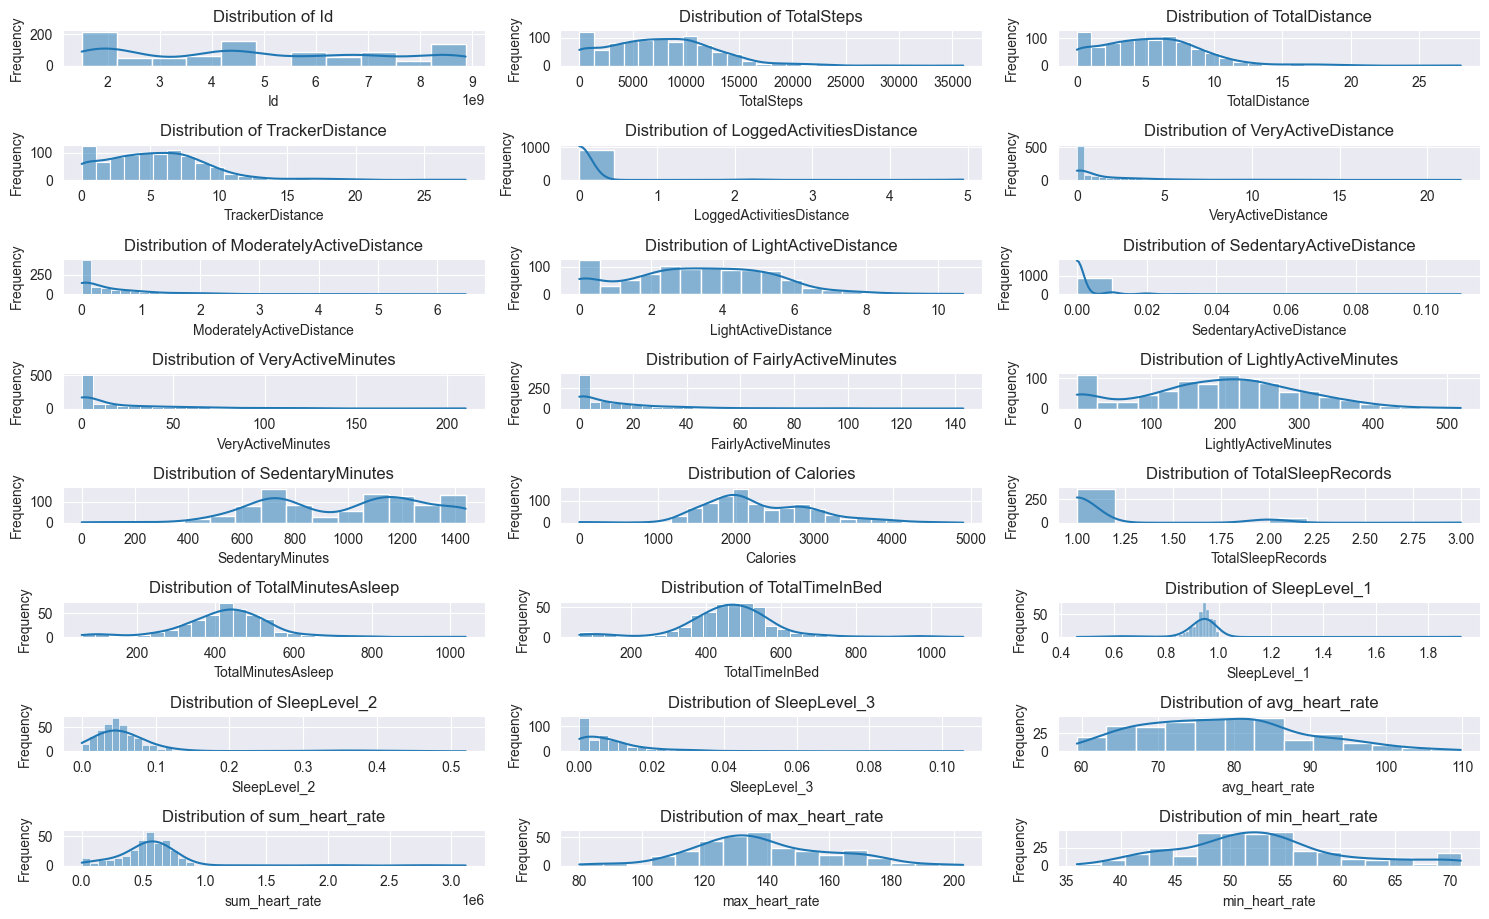

In [215]:
numerical_columns = dailyData.select_dtypes(include=['number']).columns

# Plot distributions for each numerical column
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns) // 3 + 1, 3, i)
    sns.histplot(dailyData[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3. Datan valmistelu


### Objektien muuttaminen datetime muotoon

In [216]:
dailyData['ActivityDate'] = pd.to_datetime(dailyData['ActivityDate'])
# Specify the date format explicitly
weight_data['Date'] = pd.to_datetime(weight_data['Date'], format='%m/%d/%Y %I:%M:%S %p')

### Uneen ja aktiivisuuteen liittyvän datan valmistelu
1. Poistetaan sarakkeet joilla emme tee mitään eli valitaan muuttujat

In [217]:
columns_to_drop = ['LoggedActivitiesDistance', 'TrackerDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance','TotalSleepRecords']

dailyData.drop(columns = columns_to_drop, inplace=True)
dailyData.dropna(inplace=True)

dailyData.loc[:]

,Id,ActivityDate,TotalSteps,TotalDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutesAsleep,TotalTimeInBed,SleepLevel_1,SleepLevel_2,SleepLevel_3,avg_heart_rate,sum_heart_rate,max_heart_rate,min_heart_rate
190,2026352035,2016-04-17,838,0.52,0,0,60,1053,1214,437.0,498.0,0.944954,0.055046,0.000000,68.656250,13182.0,80.0,63.0
198,2026352035,2016-04-25,6017,3.73,0,0,260,821,1576,506.0,531.0,0.980501,0.019499,0.000000,99.505814,51345.0,125.0,70.0
205,2026352035,2016-05-02,7018,4.35,0,0,355,716,1690,511.0,543.0,0.983740,0.016260,0.000000,84.134571,36262.0,122.0,70.0
212,2026352035,2016-05-09,10685,6.62,0,0,401,543,1869,531.0,556.0,0.963710,0.028226,0.008065,98.233901,132714.0,123.0,70.0
248,2347167796,2016-04-13,10352,7.01,19,32,195,676,2038,467.0,531.0,0.851351,0.144788,0.003861,73.812905,684098.0,158.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
898,8792009665,2016-04-30,7174,4.59,10,20,301,749,2896,343.0,360.0,0.952778,0.041667,0.005556,81.464642,734974.0,132.0,48.0
899,8792009665,2016-05-01,1619,1.04,0,0,79,834,1962,503.0,527.0,0.954459,0.045541,0.000000,67.810171,584049.0,123.0,43.0
900,8792009665,2016-05-02,1831,1.17,0,0,101,916,2015,415.0,423.0,0.981087,0.018913,0.000000,67.403919,553858.0,129.0,45.0
901,8792009665,2016-05-03,2421,1.55,0,0,156,739,2297,516.0,545.0,0.946789,0.049541,0.003670,74.371940,631864.0,119.0,45.0


## 4. Mallintaminen
1. Poistetaan turhat arvot

In [218]:

dailyData.dropna(inplace=True)
dailyData.loc[:]

,Id,ActivityDate,TotalSteps,TotalDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutesAsleep,TotalTimeInBed,SleepLevel_1,SleepLevel_2,SleepLevel_3,avg_heart_rate,sum_heart_rate,max_heart_rate,min_heart_rate
190,2026352035,2016-04-17,838,0.52,0,0,60,1053,1214,437.0,498.0,0.944954,0.055046,0.000000,68.656250,13182.0,80.0,63.0
198,2026352035,2016-04-25,6017,3.73,0,0,260,821,1576,506.0,531.0,0.980501,0.019499,0.000000,99.505814,51345.0,125.0,70.0
205,2026352035,2016-05-02,7018,4.35,0,0,355,716,1690,511.0,543.0,0.983740,0.016260,0.000000,84.134571,36262.0,122.0,70.0
212,2026352035,2016-05-09,10685,6.62,0,0,401,543,1869,531.0,556.0,0.963710,0.028226,0.008065,98.233901,132714.0,123.0,70.0
248,2347167796,2016-04-13,10352,7.01,19,32,195,676,2038,467.0,531.0,0.851351,0.144788,0.003861,73.812905,684098.0,158.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
898,8792009665,2016-04-30,7174,4.59,10,20,301,749,2896,343.0,360.0,0.952778,0.041667,0.005556,81.464642,734974.0,132.0,48.0
899,8792009665,2016-05-01,1619,1.04,0,0,79,834,1962,503.0,527.0,0.954459,0.045541,0.000000,67.810171,584049.0,123.0,43.0
900,8792009665,2016-05-02,1831,1.17,0,0,101,916,2015,415.0,423.0,0.981087,0.018913,0.000000,67.403919,553858.0,129.0,45.0
901,8792009665,2016-05-03,2421,1.55,0,0,156,739,2297,516.0,545.0,0.946789,0.049541,0.003670,74.371940,631864.0,119.0,45.0


### Datan mallinnus / Lineaarinen regressio ja korrelaatio

- Valitsimme lineaarisen regressiomallin, koska haluamme tutkia, miten eri aktiivisuusmuodot vaikuttavat unen määrään ja laatuun.

     TotalSteps  TotalDistance  VeryActiveMinutes  FairlyActiveMinutes  \
190         838           0.52                  0                    0   
198        6017           3.73                  0                    0   
205        7018           4.35                  0                    0   
212       10685           6.62                  0                    0   
248       10352           7.01                 19                   32   
..          ...            ...                ...                  ...   
898        7174           4.59                 10                   20   
899        1619           1.04                  0                    0   
900        1831           1.17                  0                    0   
901        2421           1.55                  0                    0   
902        2283           1.46                  0                    0   

     LightlyActiveMinutes  SedentaryMinutes  Calories  TotalMinutesAsleep  \
190                    60         

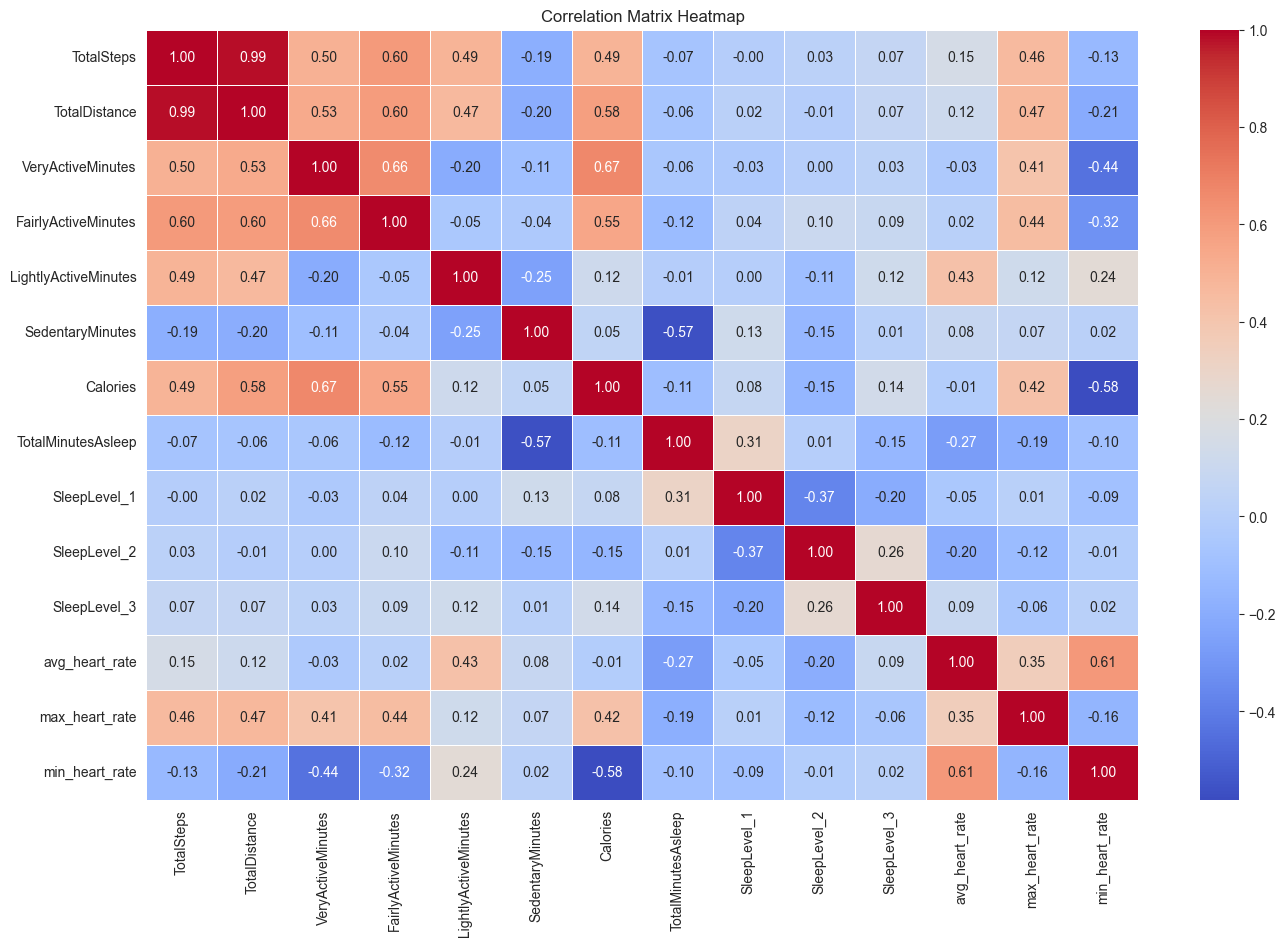

In [219]:

data_for_correlation = dailyData.drop(columns=['ActivityDate', 'Id', 'sum_heart_rate','TotalTimeInBed'])
print(data_for_correlation)

correlation_matrix = data_for_correlation.corr()

plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix Heatmap')


plt.show()

1. Aktiivisuus ja uni eivät aina kulje käsi kädessä
TotalSteps vaihtelee suuresti (838–10 685 askelta), mutta sen vaikutus unen kestoon näyttää olevan melko heikko (-0.28 regressiokertoimena).
VeryActiveMinutes ja FairlyActiveMinutes viittaavat intensiiviseen liikuntaan, ja niiden kertoimet ovat negatiivisia (-6.86 ja -16.73), mikä tarkoittaa, että enemmän aktiivisia minuutteja liittyy lyhyempään uneen. Tämä voi johtua siitä, että voimakas liikunta myöhään päivällä häiritsee unirytmiä.

2. AverageHeartRate vs. TotalMinutesAsleep = -0.337
Kohtalainen negatiivinen korrelaatio, eli korkeampi keskisyke liittyy lyhyempään unen kestoon.
Liikunnan ja unen yhteydet ovat heikkoja

In [220]:
X = dailyData[['TotalSteps', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes','SleepLevel_1', 'SleepLevel_2', 'SleepLevel_3']]
y = dailyData['TotalMinutesAsleep']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)


coefficients = model.coef_
intercept = model.intercept_

# Sovitetaan lineaarinen regressiomalli
y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)

# Tulostetaan tulokset
print("Regressiokertoimet:")
for feature, coefficients in zip(["TotalSteps", "VeryActiveMinutes",
                        "FairlyActiveMinutes",
                           "LightlyActiveMinutes", "SedentaryMinutes"], coefficients):
    print(f"{feature}: {coefficients:.2f}")

print("\n Y-Intercept:")
print(f"{intercept:.2f} (ilman liikuntaa unen keskiarvo olisi noin {intercept:.0f} minuuttia eli {intercept/60:.1f} tuntia)")

print("\n Selitysaste (R²):")
print(f"{r2:.3f} (malli selittää noin {r2*100:.1f} % unen vaihtelusta liikunnan perusteella)")

Regressiokertoimet:
TotalSteps: -0.28
VeryActiveMinutes: -6.86
FairlyActiveMinutes: -16.73
LightlyActiveMinutes: -21.57
SedentaryMinutes: -81.74

 Y-Intercept:
428.85 (ilman liikuntaa unen keskiarvo olisi noin 429 minuuttia eli 7.1 tuntia)

 Selitysaste (R²):
0.529 (malli selittää noin 52.9 % unen vaihtelusta liikunnan perusteella)



- TotalSteps (-0.28): Enemmän askeleita → unen määrä vähenee hieman, mutta vaikutus on hyvin pieni. Tämä voi tarkoittaa, että pelkkä askelmäärä ei ole merkittävä unen pituuden kannalta.
- VeryActiveMinutes (-6.86): Paljon intensiivistä liikuntaa → lyhyempi uni. Tämä voi johtua siitä, että kova treeni lisää kehon stressiä ja voi vaikeuttaa rentoutumista ennen nukkumaanmenoa.(Kellon aika?)
- FairlyActiveMinutes (-16.73): Kohtalaisen aktiivinen liikunta (ei täysin intensiivinen mutta ei kevytkään) → unen pituus lyhenee huomattavasti. Tämä voi liittyä siihen, että kohtalainen aktiivisuus ilman kunnollista palautumista häiritsee unta.
- LightlyActiveMinutes (-21.57): Pitkä kevyen aktiivisuuden kesto → unen määrä vähenee eniten kevyen liikunnan kohdalla. Tämä voi viitata siihen, että jatkuva liike ilman palautumista päivän aikana vaikuttaa negatiivisesti unen kestoon.
- SedentaryMinutes (-81.74): Pitkä paikallaanolo → merkittävä unen väheneminen. Tämä voi tarkoittaa, että vähäinen liikunta päivän aikana häiritsee unen laatua tai liittyy elämäntapatekijöihin, jotka vaikuttavat unirytmiin.

####Johtopäätös:

- Kaikki liikuntamuodot näyttävät vähentävän unen pituutta tässä mallissa, mikä voi tarkoittaa, että unen pituus ei ole suoraan sidoksissa liikunnan määrään, vaan unen laatuun.
- SedentaryMinutes:illa on suurin negatiivinen vaikutus, mikä korostaa, että liiallinen paikallaanolo voi olla unen kannalta haitallista.
- Kohtalainen ja kevyt aktiivisuus vaikuttavat unen määrään enemmän kuin erittäin intensiivinen liikunta, mikä voi liittyä päivän kuormitukseen ja palautumiseen.
- Ilman liikuntaa unen keskiarvo olisi noin 7.1 tuntia, mutta fyysiset aktiviteetit näyttävät pääosin lyhentävän sitä.


In [221]:
#Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, y_pred)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Print the results
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Squared Error (MSE): 7114.589655658687
Mean Absolute Error (MAE): 62.093905998520036
Root Mean Squared Error (RMSE): 84.34802698142195


 #### Yhteenvetona voidaan todeta, että malli ei ole täysin tarkka, mutta virhemittareiden perusteella on mahdollista parantaa ennusteiden tarkkuutta mallin optimoinnilla ja uusilla piirteillä.

Mean Squared Error (MSE): 7114.59
Tämä on virheiden neliöity keskiarvo. Korkea MSE-arvo (kuten tämä) viittaa siihen, että malli tekee suhteellisen suuria ennustamisvirheitä.

Mean Absolute Error (MAE): 62.09
Tämä mittari mittaa keskimääräisen absoluuttisen virheen, eli kuinka paljon malli keskimäärin poikkeaa todellisista arvoista. Arvo 62.09 tarkoittaa, että ennusteet poikkeavat todellisista arvoista keskimäärin noin 62 yksikköä.

Root Mean Squared Error (RMSE): 84.35
RMSE on MSE:n neliöjuuri ja tarjoaa virheiden keskikokoisen poikkeaman alkuperäisistä arvoista samalla yksiköllä kuin itse data. Arvo 84.35 tarkoittaa, että malli tekee keskimäärin 84 yksikön virheitä ennusteissaan.

Pearson correlation coefficient between SleepLevel_2 and VeryActiveMinutes: 0.00


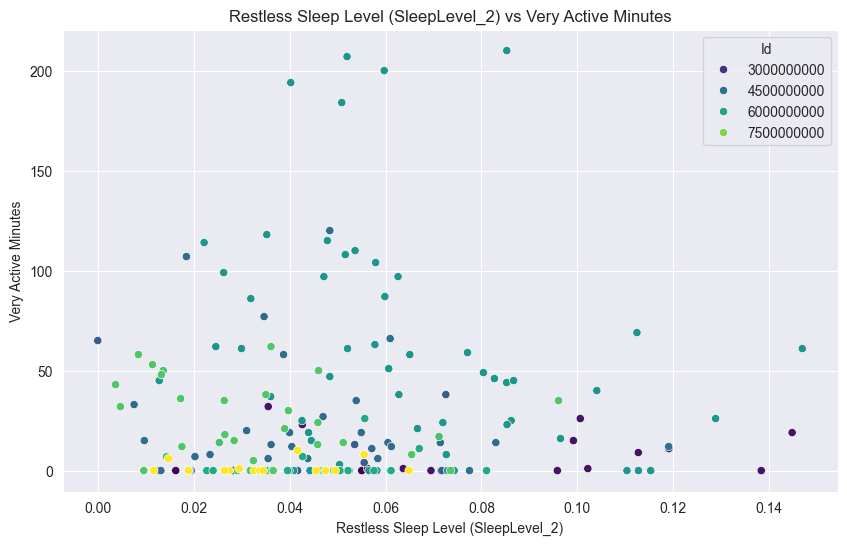

In [222]:
from scipy.stats import pearsonr

correlation, _ = pearsonr(dailyData['SleepLevel_2'], dailyData['VeryActiveMinutes'])

# Print the correlation coefficient
print(f"Pearson correlation coefficient between SleepLevel_2 and VeryActiveMinutes: {correlation:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=dailyData['SleepLevel_2'], y=dailyData['VeryActiveMinutes'], hue=dailyData['Id'], palette='viridis')


plt.title('Restless Sleep Level (SleepLevel_2) vs Very Active Minutes')
plt.xlabel('Restless Sleep Level (SleepLevel_2)')
plt.ylabel('Very Active Minutes')

# Show the plot
plt.show()

#### Pearson korrelaatio näyttää ylhäällä, että aktiivinen liikunta ja levoton uni eivät ole vahvasti korreloituneet keskenään. Tämä voi viitata siihen, että vaikka henkilö olisi levoton unen aikana, se ei välttämättä vaikuta hänen aktiivisuuteensa seuraavana päivänä.Toisaalta Aktiivinen liikunta  näyttäisi olevan korreloitunut paremmin hyvän unen kanssa.

In [223]:

corr_value, p_value = pearsonr(dailyData['avg_heart_rate'], dailyData['TotalMinutesAsleep'])
print(f"Pearson correlation: {corr_value}, p-value: {p_value}")

# Pearson correlation test between Heart Rate and Sleep Efficiency
corr_efficiency, p_value_efficiency = pearsonr(dailyData['avg_heart_rate'], dailyData['SleepLevel_2'])
print(f"Pearson correlation with Sleep Efficiency: {corr_efficiency}, p-value: {p_value_efficiency}")

Pearson correlation: -0.2723890317491158, p-value: 0.00020756704401779635
Pearson correlation with Sleep Efficiency: -0.1970583980984213, p-value: 0.007839495098096567


Correlation Matrix:
                       WeightKg  AvgTotalMinutesAsleep  AvgTotalTimeInBed  \
WeightKg               1.000000              -0.479072          -0.465287   
AvgTotalMinutesAsleep -0.479072               1.000000           0.999877   
AvgTotalTimeInBed     -0.465287               0.999877           1.000000   
AvgPoorSleep           0.635984              -0.981928          -0.978838   

                       AvgPoorSleep  
WeightKg                   0.635984  
AvgTotalMinutesAsleep     -0.981928  
AvgTotalTimeInBed         -0.978838  
AvgPoorSleep               1.000000  
--------------------
Correlation between Weight and Poor Sleep: 0.6359842910745674, p-value: 3.065782579316744e-05


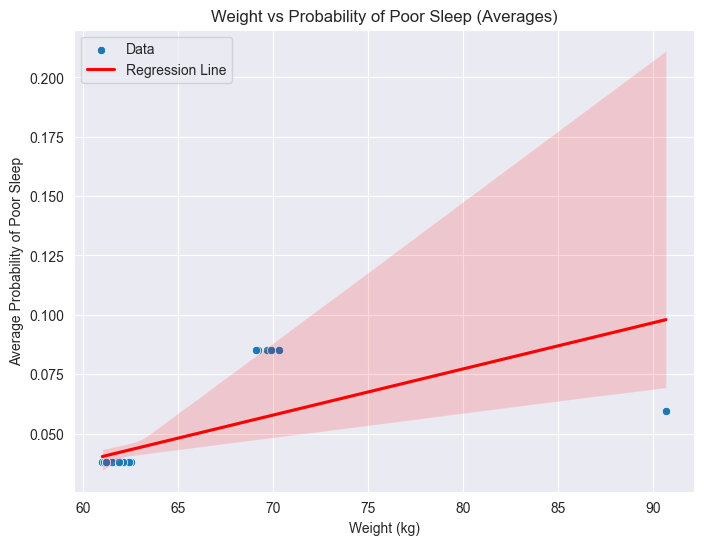

In [224]:
dailyData['ActivityDate'] = pd.to_datetime(dailyData['ActivityDate'])
weight_data['Date'] = pd.to_datetime(weight_data['Date'])

# Recalculate PoorSleep based on the SleepLevel percentages
# PoorSleep = (Restless Sleep + Awake Sleep)
dailyData['PoorSleep'] = dailyData['SleepLevel_2'] + dailyData['SleepLevel_3']

# Aggregate daily sleep data by Id (average TotalMinutesAsleep, TotalTimeInBed, PoorSleep)
agg_sleep_data = dailyData.groupby('Id').agg(
    AvgTotalMinutesAsleep=('TotalMinutesAsleep', 'mean'),
    AvgTotalTimeInBed=('TotalTimeInBed', 'mean'),
    AvgPoorSleep=('PoorSleep', 'mean')
).reset_index()

# Merge the aggregated sleep data with the weight data
merged_data = pd.merge(agg_sleep_data, weight_data[['Id', 'WeightKg']], on='Id')

# Perform correlation analysis
correlation_matrix = merged_data[['WeightKg', 'AvgTotalMinutesAsleep', 'AvgTotalTimeInBed', 'AvgPoorSleep']].corr()

# Output the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)
print('--------------------')

# Pearson correlation between 'WeightKg' and 'AvgPoorSleep'
correlation, p_value = pearsonr(merged_data['WeightKg'], merged_data['AvgPoorSleep'])
print(f"Correlation between Weight and Poor Sleep: {correlation}, p-value: {p_value}")

# Plotting the relationship between Weight and Poor Sleep
# Ensure the merged_data contains the correct weight information
merged_data['OriginalWeight'] = merged_data['WeightKg']

plt.figure(figsize=(8, 6))
sns.scatterplot(x=merged_data['OriginalWeight'], y=merged_data['AvgPoorSleep'], alpha=1, label="Data")
sns.regplot(x=merged_data['OriginalWeight'], y=merged_data['AvgPoorSleep'], scatter=False, color='red', label="Regression Line")

plt.title('Weight vs Probability of Poor Sleep (Averages)')
plt.xlabel('Weight (kg)')
plt.ylabel('Average Probability of Poor Sleep')
plt.legend()
plt.show()




### Tämä korrelaatioanalyysi antaa viitteitä siitä, miten paino (WeightKg) ja unen laatu (AvgPoorSleep) liittyvät toisiinsa.

Tulkinta ja selitys:
Painon ja huonon unen välisen korrelaation suuruus (0.636)

Positiivinen korrelaatio (0.636) tarkoittaa, että kun paino nousee, myös huonon unen määrä kasvaa. Tämä viittaa siihen, että suurempi paino voi liittyä huonompaan unenlaatuun.
Tilastollinen merkitsevyys (p-arvo ≈ 0.00003)

Pieni p-arvo (alle 0.05) tarkoittaa, että tulos ei ole sattumanvarainen, vaan painon ja unenlaadun välillä on tilastollisesti merkitsevä yhteys.

### 5. Mallin arviointi: Viides vaihe on arvioida mallia. Kuinka hyvin malli suoriutuu? Täyttääkö se liiketoiminnan vaatimukset?


Tässä mallissa virhemittarit (MSE, MAE, RMSE) osoittavat, että malli ei pysty ennustamaan dataa kovinkaan tarkasti. Virhemittarit ovat korkeat, mikä tarkoittaa, että mallin ennusteet poikkeavat merkittävästi todellisista arvoista. Tämä viittaa siihen, että mallin ei ole onnistunut löytämään riittäviä tai oikeanlaisia piirteitä ennustamiseen, ja mallin suorituskykyä tulisi parantaa.

### 6. Mallin käyttöönotto (Deployment)

#### Käyttöönoton tavoitteet

Käytännön hyödyntäminen: Muuttaa analyysin löydökset konkreettisiksi suosituksiksi unen ja aktiivisuuden optimointiin.

Ennustava analytiikka: Käyttää analyysin pohjalta kehitettyjä malleja ennustamaan unen laadun muutoksia eri tekijöiden perusteella.

Käyttäjäkeskeisyys: Tarjota käyttäjäystävällisiä keinoja unen ja aktiivisuuden seurannan parantamiseksi.

Laaja soveltaminen: Mahdollistaa sekä yksilöiden että yritysten hyödyntää tietoa paremman unen ja terveyden edistämiseksi.

Käyttöönoton vaiheet

Tiedon soveltaminen käytännössä voisi olla, yksilölle unenlaadun ja terveyden parantamiseen, yhtiöille applikaatioiden avulla voisi antaa suosituksia millä tavalla oma aktiivisuus vaikuttaa uneen ja miten unta ja terveyttä voisi parantaa unenlaadulla ja urheilulla.

#### Käytännössä käyttö

Tuloksia voi analysoida miten nämä löydökset voisivat vaikuttaa eri käyttäjäryhmiin.

Kerätään palautetta käyttäjiltä tulosten hyödyllisyydestä ja mallin toimivuudesta.

Yhteenveto


Analyysin löydökset voidaan viedä käytäntöön esimerkiksi interaktiivisten raporttien, mobiilisovellusten tai hyvinvointipalveluiden muodossa. Tärkeintä on varmistaa mallin luotettavuus, tehdä tulokset helposti ymmärrettäviksi ja optimoida niitä jatkuvasti käyttäjäpalautteen perusteella.
